# Health Insurance Cross-Sell Prediction

![Vehicle Insurance](https://previews.123rf.com/images/irinastrel123/irinastrel1231705/irinastrel123170500010/78490269-car-insurance-web-banner-types-of-insurance-cases-vector-illustration-.jpg)

This project studies a health-insurance customer base and predicts which customers are most likely to respond positively to a vehicle-insurance offer. The business problem is a classic cross-sell problem: the company already has customer information, but marketing resources are limited, so the goal is to identify the segment with the highest probability of conversion.

The workflow follows a practical data-analysis sequence: first understand the dataset, then inspect data quality, explore customer behavior, handle class imbalance, encode features, train several machine-learning models, and evaluate them with metrics that are suitable for an imbalanced binary-classification problem.


In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load


# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 5GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/health-insurance-cross-sell-prediction/sample_submission.csv
/kaggle/input/health-insurance-cross-sell-prediction/test.csv
/kaggle/input/health-insurance-cross-sell-prediction/train.csv


# Import Libraries

The first step is to import the core Python libraries used throughout the project. `numpy` and `pandas` are used for numerical operations and tabular data manipulation. `seaborn` and `matplotlib` are used for visualization because charts make it easier to detect patterns, outliers, imbalance, and relationships between features before modeling. `RandomOverSampler` is imported because the target variable is expected to be imbalanced, and imbalance can cause a model to focus too heavily on the majority class.

Doing this at the beginning keeps the notebook organized and makes the analysis reproducible: anyone rerunning the notebook can see exactly which tools are required before any data processing starts.


In [2]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import seaborn as sns
import matplotlib.pyplot as plt
from imblearn.over_sampling import RandomOverSampler
sns.set(style='whitegrid')


# Import Datasets

The training and testing files are loaded into pandas DataFrames. This step turns the raw CSV files into structured tables that can be inspected, cleaned, visualized, and passed into machine-learning models.

Separating `train` and `test` is important because the training data contains the target variable used to learn patterns, while the test data represents unseen customers. In a real business setting, this mirrors the difference between historical customers whose outcomes are known and future customers whose response needs to be predicted.


In [3]:
train = pd.read_csv("/kaggle/input/health-insurance-cross-sell-prediction/train.csv")
test = pd.read_csv("/kaggle/input/health-insurance-cross-sell-prediction/test.csv")

# Exploratory Data Analysis

Exploratory Data Analysis (EDA) is used to understand the data before building any model. The purpose is not only to create charts, but to answer practical questions: What does a typical customer look like? Are there missing values? Is the target balanced? Which variables appear related to customer response? Are there patterns that match business intuition?

This stage is important because a model can only learn from the information present in the data. If the dataset has imbalance, noisy variables, unusual distributions, or categorical values that need encoding, EDA helps reveal those issues early.


# Look At The Data

The `head()` command displays the first few rows of the training dataset. This is a quick sanity check before deeper analysis. It helps confirm that the file loaded correctly, column names are readable, values are in the expected format, and the target column `Response` is present.

This step is simple, but important: before calculating statistics or training models, we need to make sure the dataset we loaded is actually the dataset we intend to analyze.


In [4]:
train.head()

,id,Gender,Age,Driving_License,Region_Code,Previously_Insured,Vehicle_Age,Vehicle_Damage,Annual_Premium,Policy_Sales_Channel,Vintage,Response
0,1,Male,44,1,28.0,0,> 2 Years,Yes,40454.0,26.0,217,1
1,2,Male,76,1,3.0,0,1-2 Year,No,33536.0,26.0,183,0
2,3,Male,47,1,28.0,0,> 2 Years,Yes,38294.0,26.0,27,1
3,4,Male,21,1,11.0,1,< 1 Year,No,28619.0,152.0,203,0
4,5,Female,29,1,41.0,1,< 1 Year,No,27496.0,152.0,39,0


# Check Data Types

`train.info()` summarizes the number of rows, column names, non-null counts, and data types. This step answers two key questions: whether any columns contain missing values, and whether each variable is stored in a usable format.

Data types matter because models handle numeric and categorical data differently. For example, `Age` and `Annual_Premium` can be used as numeric inputs, while columns such as `Gender`, `Vehicle_Age`, and `Vehicle_Damage` need encoding before modeling. Checking this early prevents errors later in the pipeline.


In [5]:
# WITH ONE COMMAND
# Get column dtypes
# Contains isnull or not
# Total Entries
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 381109 entries, 0 to 381108
Data columns (total 12 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   id                    381109 non-null  int64  
 1   Gender                381109 non-null  object 
 2   Age                   381109 non-null  int64  
 3   Driving_License       381109 non-null  int64  
 4   Region_Code           381109 non-null  float64
 5   Previously_Insured    381109 non-null  int64  
 6   Vehicle_Age           381109 non-null  object 
 7   Vehicle_Damage        381109 non-null  object 
 8   Annual_Premium        381109 non-null  float64
 9   Policy_Sales_Channel  381109 non-null  float64
 10  Vintage               381109 non-null  int64  
 11  Response              381109 non-null  int64  
dtypes: float64(3), int64(6), object(3)
memory usage: 34.9+ MB


In [6]:
train.shape

(381109, 12)

# Check For Missing Values

Missing-value checks show whether any feature has blank or unavailable entries. This matters because many machine-learning algorithms cannot train directly on missing values, and even when they can, missingness may carry business meaning.

If missing values existed, the next decision would be whether to impute them, remove rows, create a missing-value flag, or investigate the data-collection process. In this project, checking missing values gives confidence that the following EDA and modeling steps are based on complete records.


In [7]:
train.isnull().sum()

id                      0
Gender                  0
Age                     0
Driving_License         0
Region_Code             0
Previously_Insured      0
Vehicle_Age             0
Vehicle_Damage          0
Annual_Premium          0
Policy_Sales_Channel    0
Vintage                 0
Response                0
dtype: int64

# Target Variable: Response

`Response` is the outcome we want to predict. A value of `1` means the customer is interested in vehicle insurance, while `0` means the customer is not interested. Plotting the target distribution is one of the most important early checks in a classification project because it tells us whether the model will be learning from balanced classes or from a skewed outcome.

For cross-sell problems, positive responses are often much less common than negative responses. That business reality affects both modeling and evaluation: a high accuracy score may be misleading if the model simply predicts most customers as `0`.


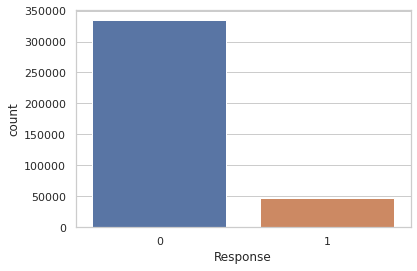

In [8]:
sns.countplot(train.Response)

### Conclusion

The number of customers with `Response = 1` is much smaller than the number of customers with `Response = 0`. This means the dataset is imbalanced: the positive class is the business-critical class, but it appears less frequently in the data.

This matters because the project goal is not just to predict the majority class correctly. The company wants to find customers who are likely to buy vehicle insurance, so the analysis should pay special attention to recall, precision, ROC-AUC, and the model's ability to rank likely responders above unlikely responders.


# Gender vs Annual Premium

This chart compares annual premium levels across gender and response groups. The reason for plotting this relationship is to check whether gender appears to separate interested and uninterested customers, and whether premium amount behaves differently within those groups.

From a business perspective, this helps answer whether demographic segmentation alone is useful or whether the response is more strongly driven by other factors such as vehicle history, previous insurance status, age, or channel. We should be careful not to overstate gender effects unless the visualization shows a clear and consistent separation.


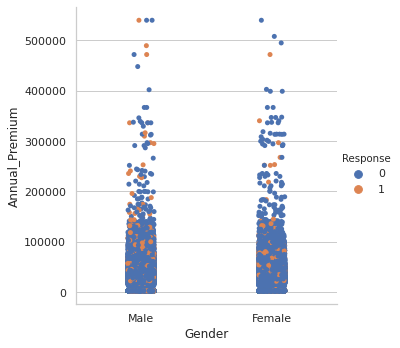

In [9]:
sns.catplot(x="Gender", y="Annual_Premium",hue="Response", data=train)

### Conclusion

The chart does not show a strong visual separation between male and female customers in terms of response. This suggests that gender alone is unlikely to be a powerful predictor of whether a customer will accept the vehicle-insurance offer.

The practical takeaway is that gender may still be included as a feature after encoding, but it should not be treated as the main driver of the recommendation strategy. Stronger behavioral or product-related variables are likely needed to identify high-intent customers.


# Vehicle Damage vs Policy Sales Channel

This plot examines how `Vehicle_Damage` and `Policy_Sales_Channel` relate to customer response. The reason for looking at vehicle damage is that it captures a customer's perceived need for vehicle protection: someone whose vehicle has been damaged may be more aware of risk and therefore more receptive to insurance.

The sales channel is included because response behavior can differ by acquisition channel. Some channels may reach customers with higher purchase intent, while others may contain broader, lower-intent audiences. Looking at both variables together helps connect customer need with marketing-channel effectiveness.


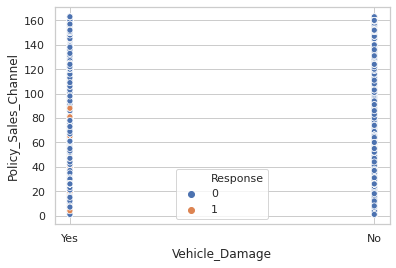

In [10]:
sns.scatterplot(x="Vehicle_Damage", y="Policy_Sales_Channel",hue="Response", data=train)

### Conclusion

Customers with `Vehicle_Damage = No` appear to have a much weaker response pattern than customers who have experienced vehicle damage. This makes business sense: if a customer has not experienced vehicle damage, the perceived urgency of buying vehicle insurance may be lower.

This feature is likely useful because it reflects risk awareness and purchase motivation, not just demographics. In a cross-sell model, variables connected to customer need often carry stronger signal than broad profile variables.


# Previously Insured vs Policy Sales Channel

This chart compares previous insurance status with sales channel and response. The reason for this step is to test a direct business hypothesis: customers who already have vehicle insurance may have less need for another policy, while customers who are not previously insured may represent a stronger cross-sell opportunity.

Including the sales channel helps identify whether certain channels are better at reaching uninsured customers or customers who are still open to switching or purchasing additional coverage.


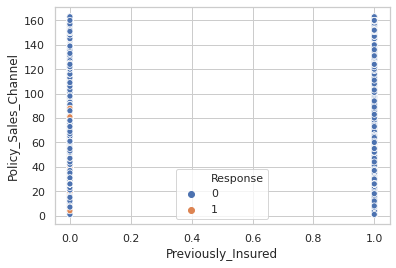

In [11]:
sns.scatterplot(x="Previously_Insured", y="Policy_Sales_Channel",hue="Response", data=train)

### Conclusion

Previously insured customers generally show lower response potential because their immediate need for a new vehicle-insurance product is already satisfied. Customers who are not previously insured are more likely to represent the true growth opportunity for the business.

This is an important feature because it is closely tied to customer intent. It also helps the marketing team avoid wasting budget on customers who are less likely to convert because they already have similar coverage.


# Annual Premium vs Policy Sales Channel

This plot explores whether annual premium levels vary across sales channels and response groups. The purpose is to understand whether price-related behavior interacts with channel behavior. If certain channels contain customers with higher premiums and stronger response, those channels may deserve different targeting or messaging.

Annual premium can also act as a proxy for customer value. A customer with a higher premium may represent higher revenue potential, but only if their probability of response is also meaningful. That is why the analysis considers premium together with response instead of looking at premium alone.


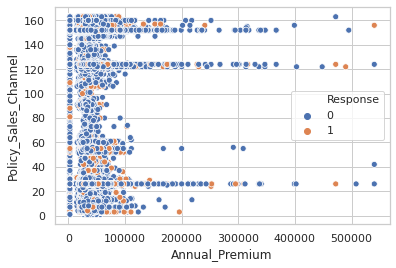

In [12]:
sns.scatterplot(x="Annual_Premium", y="Policy_Sales_Channel",hue="Response", data=train)

### Why This Step Matters

Annual premium is not only a numeric feature; it can influence both customer affordability and customer value. A very high premium may indicate a more valuable customer, but it may also make the offer feel expensive. By comparing premium with sales channel and response, we can see whether some channels are associated with better conversion at different premium levels.


In [13]:
# sns.swarmplot(x="Annual_Premium", y="Policy_Sales_Channel",hue="Response", data=train)

# Age Distribution Of Customers

Age is examined because insurance needs, risk perception, and purchase behavior often vary by life stage. Younger customers, middle-aged customers, and older customers may respond differently to a vehicle-insurance offer because they differ in driving habits, income stability, vehicle ownership, and risk awareness.

The age distribution also helps identify whether the dataset is concentrated in a particular demographic group. If most customers come from a narrow age range, the model may perform better for that group than for underrepresented age segments.


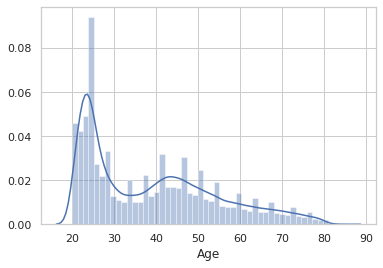

In [14]:
sns.distplot(train.Age)

### Why This Step Matters

The distribution plot shows whether customer ages are evenly spread or concentrated in specific ranges. This matters because age can create non-linear effects: the response rate may rise or fall at different life stages instead of changing in a straight line. Tree-based models are useful later because they can capture these kinds of threshold-based relationships.


/opt/conda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


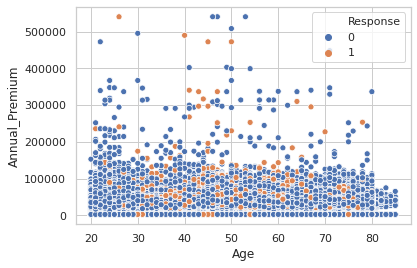

In [15]:
sns.scatterplot(x="Age", y="Annual_Premium",hue="Response", data=train)

### Age vs Annual Premium

This chart checks whether premium levels vary by age and whether responders cluster in specific age-premium combinations. The purpose is to look for interaction effects: age alone may not explain response, and premium alone may not explain response, but certain combinations may reveal higher-value or higher-intent customer groups.


In [16]:
# sns.swarmplot(x="Age", y="Annual_Premium",hue="Response", data=train)

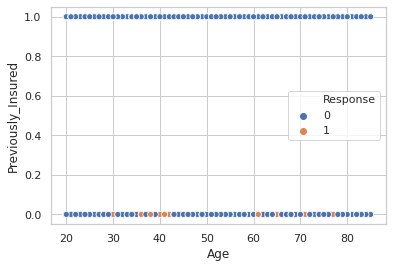

In [17]:
sns.scatterplot(x="Age", y="Previously_Insured",hue="Response", data=train)

### Age vs Previously Insured

This step investigates whether previous insurance status differs by age and whether that relationship affects response. It is useful because previous insurance status is directly connected to customer need, while age gives context about customer life stage. Together, they can help explain why some customers are easier to convert than others.


/opt/conda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


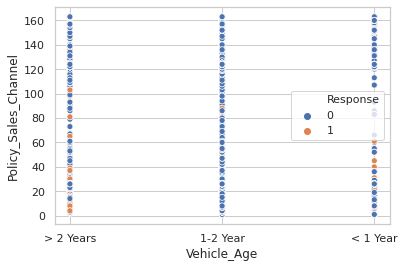

In [18]:
sns.scatterplot(x="Vehicle_Age", y="Policy_Sales_Channel",hue="Response", data=train)


### Vehicle Age And Sales Channel

Vehicle age can influence insurance interest because newer and older vehicles may create different customer motivations. A customer with a newer vehicle may want protection for a valuable asset, while a customer with an older vehicle may evaluate insurance differently. Comparing this with sales channel helps identify whether certain channels are reaching customers with different vehicle profiles.


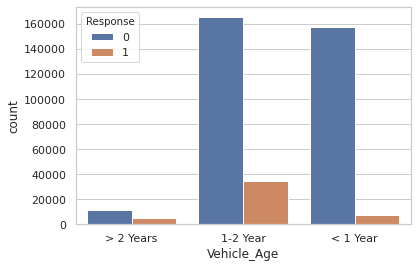

In [19]:
sns.countplot(x="Vehicle_Age", hue="Response", data=train)

### Vehicle Age vs Response

This count plot gives a clearer class-level view of response by vehicle age. Count plots are useful here because categorical variables are easier to compare by frequency than by scatter position. The goal is to see whether one vehicle-age category contributes disproportionately to positive responses.


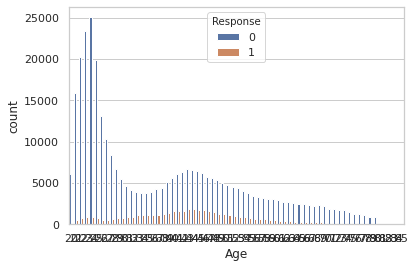

In [20]:
sns.countplot(x="Age", hue="Response", data=train)

### Age vs Response Counts

This chart checks whether positive responses are concentrated in particular ages. The reason for doing this is to identify potential customer segments for targeting. If specific age bands show higher response, the model and marketing strategy can both use that information.


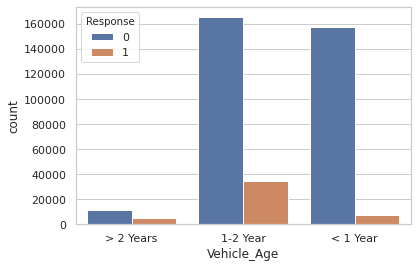

In [21]:
sns.countplot(x="Vehicle_Age", hue="Response", data=train)

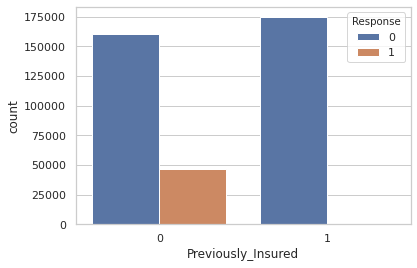

In [22]:
sns.countplot(x="Previously_Insured", hue="Response", data=train)

### Previously Insured vs Response Counts

This count plot directly tests one of the strongest business hypotheses in the dataset: customers who already have insurance may be less likely to respond to another insurance offer. The chart is important because it translates a business assumption into evidence from the data.


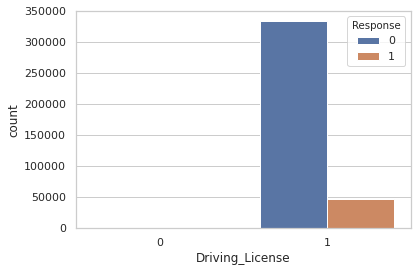

In [23]:
sns.countplot(x="Driving_License", hue="Response", data=train)

### Driving License vs Response

Driving license status is checked because vehicle insurance is only meaningful for customers who are connected to driving. If almost all customers have a license, the feature may add little predictive value. If there is variation, it may help the model distinguish eligible or more relevant customers.


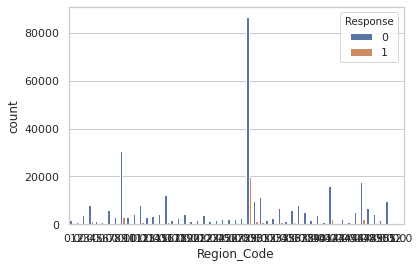

In [24]:
sns.countplot(x="Region_Code", hue="Response", data=train)

### Region Code vs Response

Region can capture geographic differences in customer behavior, market competition, income patterns, or sales coverage. Even if region codes are anonymized, they may still contain predictive signal. This step checks whether response is concentrated in certain regions.


/opt/conda/lib/python3.7/site-packages/IPython/core/pylabtools.py:132: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


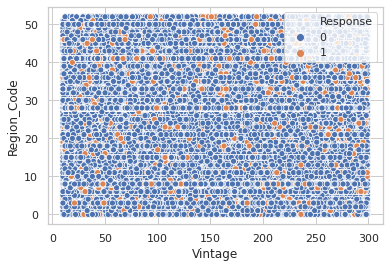

In [25]:
sns.scatterplot(x="Vintage",y="Region_Code" , hue="Response", data=train)

### Vintage vs Region Code

`Vintage` represents how long the customer has been associated with the company. Comparing vintage with region and response helps explore whether customer tenure interacts with geography. Long-tenure customers may trust the company more, but response can still vary by local market conditions.


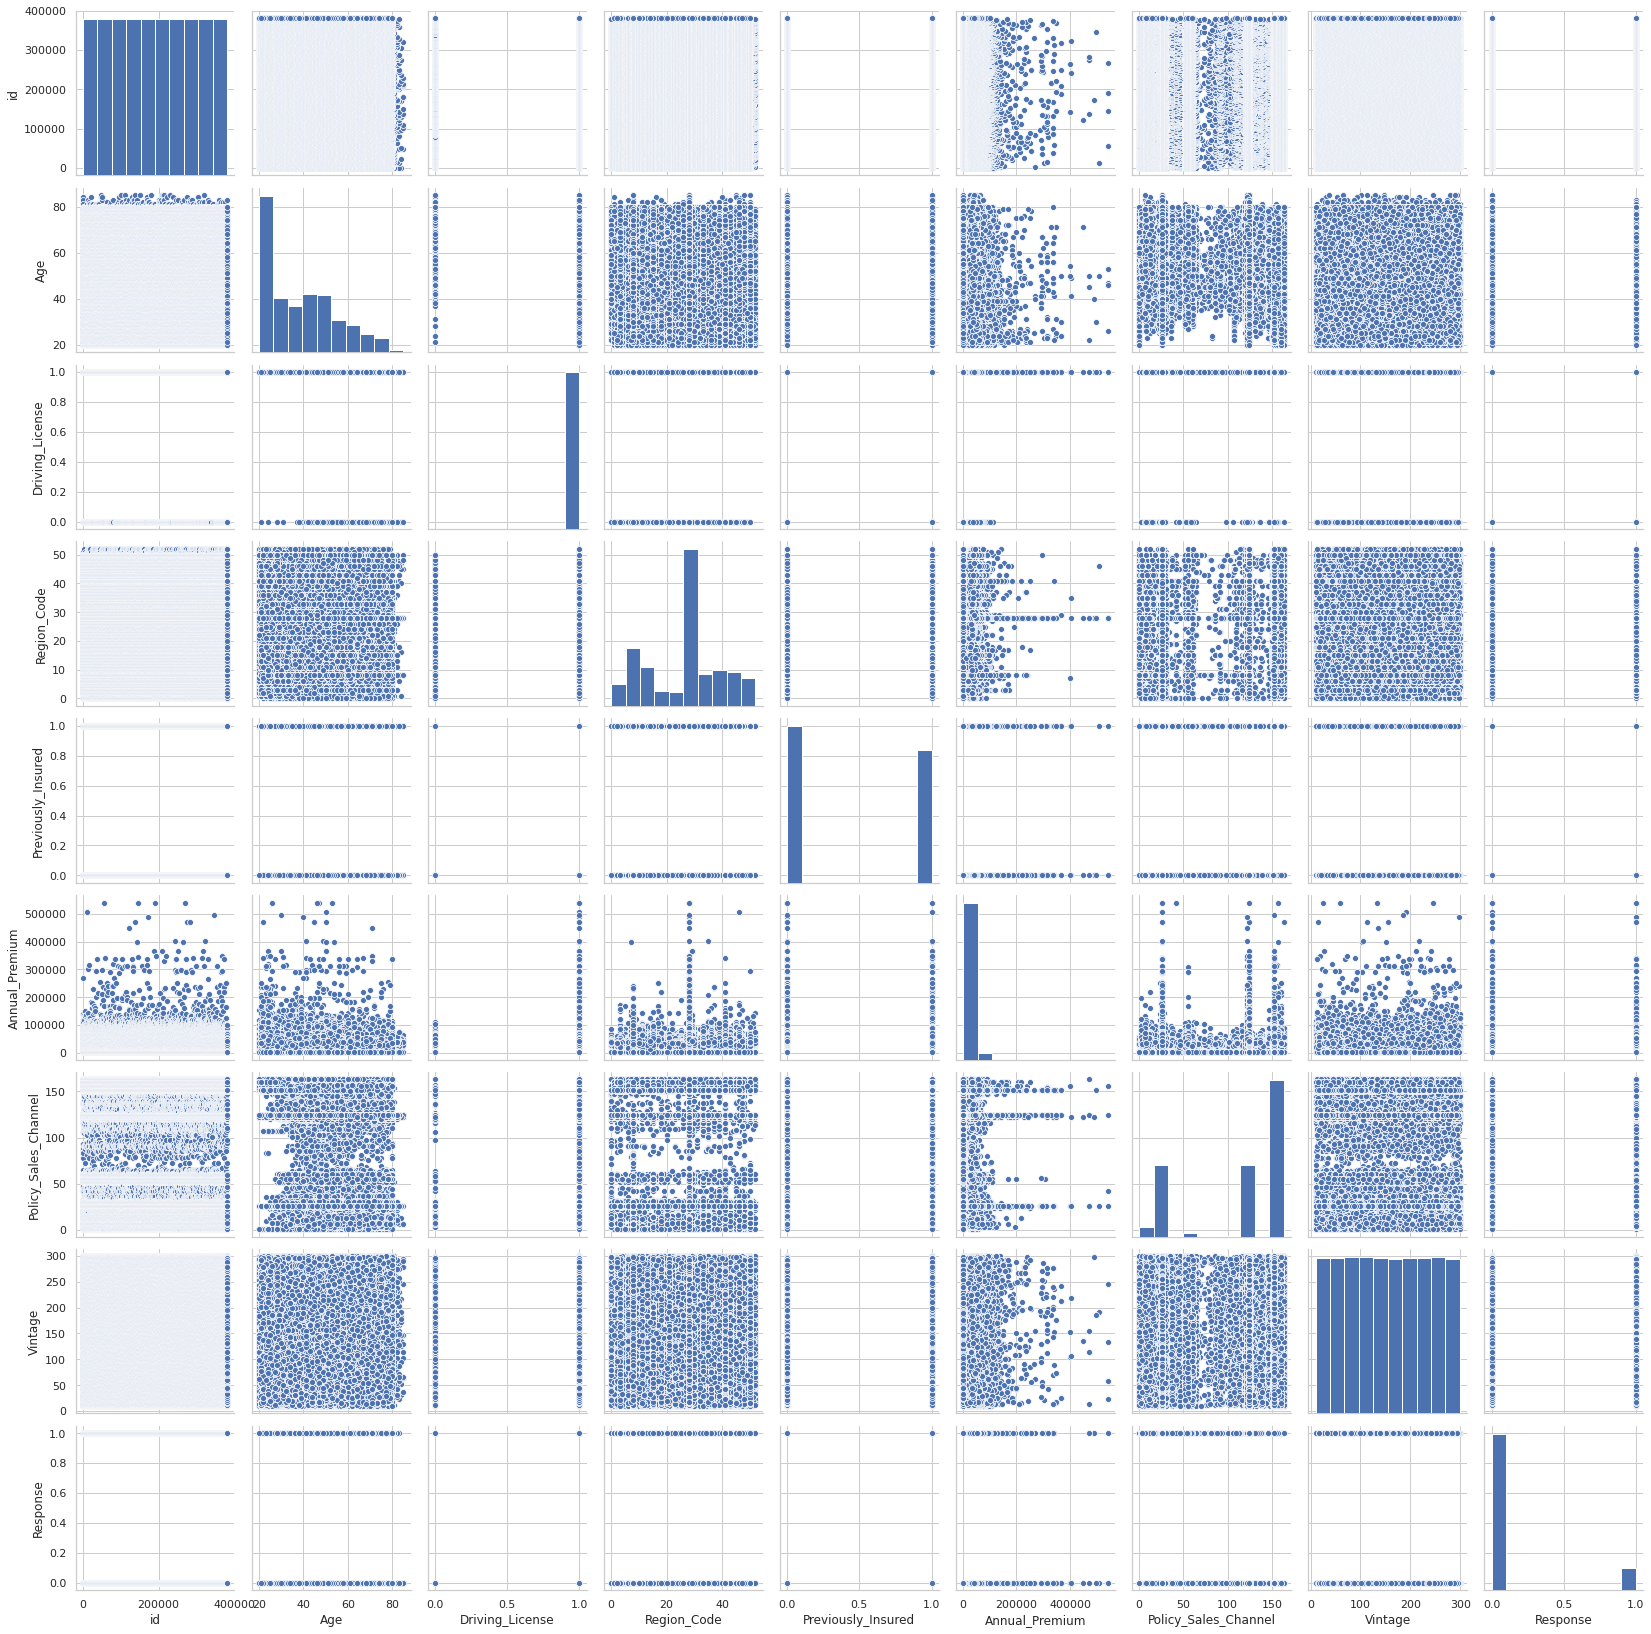

In [26]:
sns.pairplot(data=train)

### Pairplot Summary

The pairplot gives a broad overview of pairwise relationships across numeric variables. It is not used to make final decisions by itself; instead, it helps spot obvious clusters, outliers, correlations, or separations that may deserve deeper investigation. This is a useful final EDA scan before moving into preprocessing and modeling.


# Handling Imbalanced Data: Oversampling

The target variable is imbalanced, with many more non-responders than responders. Oversampling is used to increase the representation of the minority class (`Response = 1`) so the model has more opportunities to learn the patterns associated with interested customers.

The reason this matters is that a model trained on a highly imbalanced dataset may become conservative and predict most customers as `0`. That could produce high accuracy but fail the actual business goal: finding potential buyers. By balancing the classes, the model is encouraged to pay more attention to the positive class.

In a production-grade workflow, oversampling should be applied only to the training split, not to the validation or test split, to avoid data leakage. The conceptual reason remains the same: rebalance the learning data while keeping evaluation data as realistic as possible.


In [27]:

train_os=RandomOverSampler(random_state=42)
X=train.drop(['Response'],axis=1)
y=train['Response']

X_os,y_os=train_os.fit_sample(X,y)

In [28]:
from collections import Counter
print('Original dataset shape {}'.format(Counter(y)))
print('Resampled dataset shape {}'.format(Counter(y_os))) 

Original dataset shape Counter({0: 334399, 1: 46710})
Resampled dataset shape Counter({1: 334399, 0: 334399})


### Result Of Oversampling

The class counts before and after oversampling confirm whether the balancing step worked. This check is necessary because preprocessing should always be validated. If the class distribution did not change as expected, the model would still be trained on the original imbalance and could remain biased toward predicting non-response.


# One-Hot Encoding

Machine-learning models require numerical input, but several useful columns are categorical, such as `Gender`, `Vehicle_Age`, and `Vehicle_Damage`. Encoding converts these labels into numeric variables while preserving their category information.

`Gender` is mapped manually because it has two values. Other categorical variables are converted with `get_dummies`, which creates separate indicator columns for categories. `drop_first=True` is used to reduce redundant columns and avoid perfect multicollinearity, where one category can be perfectly inferred from the others.

This step is necessary because the model cannot learn from raw text labels directly. Encoding turns business categories into a format that algorithms such as Random Forest, XGBoost, and LightGBM can process.


In [29]:
X_os['Gender'] = X_os['Gender'].map( {'Female': 0, 'Male': 1} ).astype(int)

In [30]:
# Convert categorical variable into dummy/indicator variables
# Learn More https://pandas.pydata.org/pandas-docs/stable/reference/api/pandas.get_dummies.html?highlight=dummies#pandas.get_dummies
X_os=pd.get_dummies(X_os,drop_first=True)

### Train-Test Split And Feature Selection

After encoding, the feature matrix is prepared by removing columns that are not useful for model learning in this version of the project. The `id` column is removed because it is an identifier, not a behavioral feature. Some additional columns are also dropped to simplify the model input.

The train-test split creates separate data for learning and evaluation. This is essential because evaluating on the same data used for training would overestimate performance and would not reflect how the model behaves on new customers.


In [31]:
from sklearn.model_selection import train_test_split
x = X_os.drop(labels= ['id','Region_Code',"Driving_License"], axis = 1)

y=y_os

x_train,x_test,y_train,y_test = train_test_split(x,y, random_state = 0)


In [32]:
x_train.shape

(501598, 9)

In [33]:
x_train.info()

<class 'pandas.core.frame.DataFrame'>
Int64Index: 501598 entries, 543165 to 305711
Data columns (total 9 columns):
 #   Column                 Non-Null Count   Dtype  
---  ------                 --------------   -----  
 0   Gender                 501598 non-null  int64  
 1   Age                    501598 non-null  int64  
 2   Previously_Insured     501598 non-null  int64  
 3   Annual_Premium         501598 non-null  float64
 4   Policy_Sales_Channel   501598 non-null  float64
 5   Vintage                501598 non-null  int64  
 6   Vehicle_Age_< 1 Year   501598 non-null  uint8  
 7   Vehicle_Age_> 2 Years  501598 non-null  uint8  
 8   Vehicle_Damage_Yes     501598 non-null  uint8  
dtypes: float64(2), int64(4), uint8(3)
memory usage: 28.2 MB


# Data Modeling And Evaluation

After cleaning, balancing, and encoding the data, the next step is to train classification models. This project compares tree-based models because they are strong choices for structured tabular data: they can capture non-linear relationships, handle interactions between features, and often perform well without heavy feature scaling.

Evaluation is especially important because this is an imbalanced classification problem. Accuracy alone is not enough. Metrics such as classification report, ROC curve, and AUC help evaluate whether the model can separate likely responders from non-responders and support better marketing decisions.


In [34]:
from sklearn.model_selection import RandomizedSearchCV
from sklearn.model_selection import cross_val_score
from sklearn.ensemble import RandomForestClassifier
from scipy.stats import randint
import pickle
import xgboost as xgb
import lightgbm as lgb
from sklearn.metrics import accuracy_score
# import packages for hyperparameters tuning
from hyperopt import STATUS_OK, Trials, fmin, hp, tpe
from sklearn.model_selection import train_test_split, RandomizedSearchCV, StratifiedKFold, KFold, GridSearchCV
from sklearn.metrics import f1_score, roc_auc_score,accuracy_score,confusion_matrix, precision_recall_curve, auc, roc_curve, recall_score, classification_report 

In [ ]:
x_train.shape

In [ ]:
x_train

### Why Inspect The Training Matrix

Checking `x_train.shape`, `x_train.info()`, and the training table confirms that preprocessing produced the expected modeling dataset. This step verifies the number of rows, number of features, data types, and final column names before training begins.

This matters because many modeling errors come from preprocessing mistakes: unexpected object columns, missing dummy variables, duplicated identifiers, or mismatched train/test features. Inspecting the matrix before fitting models reduces that risk.


# Random Forest Classifier

Random Forest is used as a strong baseline model. It builds many decision trees and combines their predictions, which usually improves stability compared with a single decision tree. This is useful for customer-response prediction because the relationship between features and response may be non-linear and may involve feature interactions.

`RandomizedSearchCV` is used to search across different hyperparameter combinations. Instead of manually choosing one model configuration, the search tests multiple options for tree depth, splitting rules, leaf size, and number of estimators. Cross-validation helps estimate how well each configuration generalizes beyond one train-test split.


In [ ]:
random_search = {'criterion': ['entropy', 'gini'],
               'max_depth': [2,3,4,5,6,7,10],
               'min_samples_leaf': [4, 6, 8],
               'min_samples_split': [5, 7,10],
               'n_estimators': [300]}

clf = RandomForestClassifier()
model = RandomizedSearchCV(estimator = clf, param_distributions = random_search, n_iter = 10, 
                               cv = 4, verbose= 2, random_state= 101, n_jobs = -1)
model.fit(x_train,y_train)

# Save Model

The trained Random Forest model is saved with `pickle`. Saving the model is important because training can be time-consuming, especially after hyperparameter search. Once saved, the model can be loaded again for evaluation, comparison, or deployment without retraining from scratch.

This also makes the workflow more reproducible: the same trained object can be reused later to generate predictions or compare against other models.


In [ ]:
filename = 'rf_model.sav'
pickle.dump(model, open(filename, 'wb'))

In [ ]:
filename = 'rf_model.sav'

In [ ]:
rf_load = pickle.load(open(filename, 'rb'))

### Why Reload The Saved Model

Reloading the model confirms that the saved file can actually be used again. This is a practical workflow check: a model artifact is only useful if it can be restored reliably for later prediction, evaluation, or deployment.


# Evaluate Model

The model is evaluated on the test split to estimate performance on data it did not directly train on. This step is where the project moves from model building to model validation.

The main question is not only whether the model predicts many cases correctly, but whether it can identify the minority positive class well enough to be useful for cross-selling. In business terms, the evaluation asks: Can this model help the company prioritize customers who are more likely to respond?


In [ ]:
y_pred=model.predict(x_test)

## Classification Report

The classification report provides precision, recall, F1-score, and support for each class. These metrics are useful because they show different types of model behavior.

Precision answers: among customers predicted as interested, how many actually are interested? Recall answers: among all truly interested customers, how many did the model find? F1-score balances precision and recall. For this project, recall for `Response = 1` is especially important if the goal is to avoid missing potential buyers, while precision matters if marketing budget is limited and outreach should be highly targeted.


In [ ]:
print (classification_report(y_test, y_pred))


## ROC Curve And AUC Of Random Forest Classifier

The ROC curve shows how the true positive rate and false positive rate change across different classification thresholds. This is useful because the default threshold of 0.5 may not be the best business decision. For example, a marketing team may choose a lower threshold to reach more potential buyers, or a higher threshold to focus only on the strongest leads.

AUC summarizes the model's ranking ability. A higher AUC means the model is better at assigning higher scores to responders than to non-responders. This is often more informative than accuracy in imbalanced problems because it evaluates separation across thresholds.


In [ ]:
y_score = model.predict_proba(x_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_score)

title('Random Forest ROC curve: CC Fraud')
xlabel('FPR (Precision)')
ylabel('TPR (Recall)')

plot(fpr,tpr)
plot((0,1), ls='dashed',color='black')
plt.show()
print ('Area under curve (AUC): ', auc(fpr,tpr))


In [ ]:
roc_auc_score(y_test, y_score)

### Random Forest Evaluation Summary

The AUC score provides a single-number summary of the ROC curve. It should be interpreted together with the classification report. A model can have good ranking ability but still require threshold tuning before it becomes useful for a real marketing campaign.


# XGBoost Classifier

XGBoost is tested because gradient-boosted trees are often very effective for tabular prediction tasks. Unlike Random Forest, which builds many trees independently, boosting builds trees sequentially, where each new tree focuses on correcting errors made by earlier trees.

This can improve predictive power when the data contains complex patterns. Hyperparameter tuning is included because XGBoost performance depends strongly on settings such as maximum depth, regularization, child weight, and column sampling. Tuning helps control overfitting while still allowing the model to learn meaningful customer-response signals.


In [ ]:
space={ 'max_depth': hp.quniform("max_depth", 3,18,1),
        'gamma': hp.uniform ('gamma', 1,11),
        'reg_alpha' : hp.quniform('reg_alpha', 40,180,1),
        'reg_lambda' : hp.uniform('reg_lambda', 0,1),
        'colsample_bytree' : hp.uniform('colsample_bytree', 0.5,1),
        'min_child_weight' : hp.quniform('min_child_weight', 0, 10, 1),
        'n_estimators': 300,
        'seed': 0
    }

### Hyperparameter Search Space For XGBoost

The search space defines which model configurations Hyperopt is allowed to test. This is important because boosting models can overfit if they are too complex, but underfit if they are too restricted. Parameters such as tree depth, regularization, and child weight control the balance between learning detailed patterns and staying general enough for unseen customers.


In [ ]:
def objective(space):
    clf=xgb.XGBClassifier(
                    n_estimators =space['n_estimators'], max_depth = int(space['max_depth']),learning_rate=0.01,gamma = space['gamma'],
                    reg_alpha = int(space['reg_alpha']),min_child_weight=int(space['min_child_weight']),
                    colsample_bytree=int(space['colsample_bytree']))
    
    evaluation = [(x_train, y_train), (x_test, y_test)]
    
    clf.fit(x_train, y_train,
            eval_set=evaluation, eval_metric="auc",
            early_stopping_rounds=10,verbose=False)
    

    pred = clf.predict(x_test)
    y_score = model.predict_proba(x_test)[:,1]
    accuracy = accuracy_score(y_test, pred>0.5)
    Roc_Auc_Score = roc_auc_score(y_test, y_score)
    print ("ROC-AUC Score:",Roc_Auc_Score)
    print ("SCORE:", accuracy)
    return {'loss': -Roc_Auc_Score, 'status': STATUS_OK }

In [ ]:
x_train=x_train.rename(columns={"Vehicle_Age_< 1 Year": "Vehicle_Age_lt_1_Year", "Vehicle_Age_> 2 Years": "Vehicle_Age_gt_2_Years"})
x_test=x_test.rename(columns={"Vehicle_Age_< 1 Year": "Vehicle_Age_lt_1_Year", "Vehicle_Age_> 2 Years": "Vehicle_Age_gt_2_Years"})

In [ ]:
trials = Trials()

best_hyperparams = fmin(fn = objective,
                        space = space,
                        algo = tpe.suggest,
                        max_evals = 100,
                        trials = trials)

In [ ]:
print("The best hyperparameters are : ","\n")
print(best_hyperparams)

### Choosing The Tuned XGBoost Model

After Hyperopt searches for strong parameter combinations, the selected values are used to train a final XGBoost model. This separates the tuning stage from the final fitting stage: first search for a good configuration, then train a model with that configuration for evaluation and comparison.


In [ ]:
xgb_model=xgb.XGBClassifier(n_estimators = space['n_estimators'], max_depth = 7, gamma = 4.0388607178326605, reg_lambda = 0.26955899476862166,
                            reg_alpha = 66.0, min_child_weight=4.0,colsample_bytree = 0.8844758548525424 )
    


In [ ]:
xgb_model.fit(x_train,y_train)

In [ ]:
filename = 'xgboost_model.sav'
pickle.dump(xgb_model, open(filename, 'wb'))

### Saving The XGBoost Model

The fitted XGBoost model is saved so it can be reused without running the hyperparameter search again. This is especially valuable because tuning boosted models can be computationally expensive.


# ROC Curve And AUC Of XGBoost Classifier

The XGBoost model is evaluated using ROC curve and AUC for the same reason as the Random Forest model: the project needs to know how well the model ranks likely responders against non-responders across thresholds.

Using the same evaluation method across models makes the comparison fairer. If XGBoost has a higher AUC, it suggests stronger ranking performance; if it has similar AUC but different precision-recall tradeoffs, the final choice may depend on the business cost of false positives versus false negatives.


In [ ]:
y_score = xgb_model.predict_proba(x_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_score)

title('XGBoost ROC curve')
xlabel('FPR (Precision)')
ylabel('TPR (Recall)')

plot(fpr,tpr)
plot((0,1), ls='dashed',color='black')
plt.show()
print ('Area under curve (AUC): ', auc(fpr,tpr))

### XGBoost Evaluation Summary

The AUC result should be compared against the Random Forest AUC using the same test data. The goal is to determine whether boosting improves the model's ability to rank customers by likelihood of response. A higher score would support using XGBoost as the stronger candidate model.


## LightGBM Classifier

LightGBM is another gradient-boosting algorithm designed to train efficiently on large tabular datasets. It is included because it often achieves strong performance with faster training than many other boosting methods.

The reason to compare LightGBM with Random Forest and XGBoost is model selection. Different algorithms can capture patterns differently, and the best model is not always known in advance. By training multiple strong candidates and evaluating them consistently, the project can choose the model that best fits the business goal.


In [ ]:
x_test['Vehicle_Age_lt_1_Year']=x_test['Vehicle_Age_lt_1_Year'].astype('int')
x_test['Vehicle_Age_gt_2_Years']=x_test['Vehicle_Age_gt_2_Years'].astype('int')
x_test['Vehicle_Damage_Yes']=x_test['Vehicle_Damage_Yes'].astype('int')


### Preparing Data Types For LightGBM

Some encoded columns are explicitly converted to integers before LightGBM modeling. This keeps feature types consistent and avoids issues where dummy variables may be stored as boolean or another type. Consistent numeric types make the modeling pipeline more reliable.


In [ ]:
random_state=42
n_iter=50
num_folds=2
kf = KFold(n_splits=num_folds, random_state=random_state,shuffle=True)

### Cross-Validation Setup For LightGBM

K-fold cross-validation is used to evaluate candidate LightGBM parameter settings across multiple splits of the training data. This gives a more stable estimate than relying on one split only. The random state is fixed so the results are reproducible.


In [ ]:
def gb_mse_cv(params, random_state=random_state, cv=kf, X=x_train, y=y_train):
    # the function gets a set of variable parameters in "param"
    params = {'n_estimators': int(params['n_estimators']), 
              'max_depth': int(params['max_depth']), 
             'learning_rate': params['learning_rate']}
    
    # we use this params to create a new LGBM Regressor
    model = lgb.LGBMClassifier(random_state=42, **params)
    
    # and then conduct the cross validation with the same folds as before
    score = -cross_val_score(model, X, y, cv=cv, scoring="roc_auc", n_jobs=-1).mean()

    return score


### LightGBM Objective Function

The objective function tells Hyperopt what to minimize. Here, the model is evaluated using ROC-AUC through cross-validation, and the negative score is returned because Hyperopt minimizes objective values. This connects the tuning process directly to the project's evaluation goal.


In [ ]:
%%time

# possible values of parameters
space={'n_estimators': hp.quniform('n_estimators', 100, 2000, 1),
       'max_depth' : hp.quniform('max_depth', 2, 20, 1),
       'learning_rate': hp.loguniform('learning_rate', -5, 0)
      }

# trials will contain logging information
trials = Trials()

best=fmin(fn=gb_mse_cv, # function to optimize
          space=space, 
          algo=tpe.suggest, # optimization algorithm, hyperotp will select its parameters automatically
          max_evals=n_iter, # maximum number of iterations
          trials=trials, # logging
          rstate=np.random.RandomState(random_state) # fixing random state for the reproducibility
         )

# computing the score on the test set
model = lgb.LGBMClassifier(random_state=random_state, n_estimators=int(best['n_estimators']),
                      max_depth=int(best['max_depth']),learning_rate=best['learning_rate'])
model.fit(x_train,y_train)

preds = [pred[1] for pred in model.predict_proba(x_test)]
score = roc_auc_score(y_test, preds, average = 'weighted')

In [ ]:
print("Best auc-roc score",score)


### Best LightGBM Score

Printing the best score makes the tuning result visible and allows comparison with the other models. This is important because model selection should be based on evidence, not only on the assumption that a more advanced algorithm will perform better.


In [ ]:
y_score = model.predict_proba(x_test)[:,1]
fpr, tpr, _ = roc_curve(y_test, y_score)

title('LGBM ROC curve: CC Fraud')
xlabel('FPR (Precision)')
ylabel('TPR (Recall)')

plot(fpr,tpr)
plot((0,1), ls='dashed',color='black')
plt.show()
print ('Area under curve (AUC): ', auc(fpr,tpr))


### LightGBM Evaluation Summary

The final ROC curve and AUC show how well the tuned LightGBM model separates responders from non-responders. Comparing this curve with Random Forest and XGBoost helps choose the most useful model for prioritizing customer outreach.


# Final Project Takeaway

This notebook follows a complete machine-learning workflow for a health-insurance cross-sell problem: load the data, inspect quality, explore customer behavior, handle target imbalance, encode categorical features, train multiple tree-based classifiers, and compare performance using classification metrics and ROC-AUC.

The most important analytical idea is that the project is not simply predicting a label. It is helping the business prioritize outreach. Features such as vehicle damage, previous insurance status, age, annual premium, and sales channel are valuable because they connect customer profile, customer need, and marketing context. The final model can therefore support a more efficient targeting strategy by ranking customers according to their likelihood of responding to a vehicle-insurance offer.
